# Where the errors occur

A compact localization of reconstruction and prediction errors of both axes: by m/z window, by image, by input intensity, by distance to the tissue border and by class, as a basis for later comparisons with pretrained models.

## Introduction

The earlier notebooks answer each question on one axis; here the same breakdowns are placed side by side for
both axes so that the regions responsible for most error, and those that change between populations, are
visible at once.

### Assumptions

* `test` pixels come from training images and are spatially correlated with training pixels; `heldout_image`
  pixels come from three images never seen during training. Generalization to new images is therefore judged on
  `heldout_image`, generalization to new pixels on `test`.
* Repetitions differ only in initialization and training seed; they share the split. Five repetitions per axis
  are the experimental units for model-level statements; pixels are not independent units.

* Both axes are evaluated on identical pixels (same source spectra), so per-pixel comparisons are paired. The
  models of the two axes are independent; repetition $r$ of one axis is paired with repetition $r$ of the other only
  for convenience (the seeds are equal but the models are not related).
* Global $W_1$ values are not comparable across axes: the wide axis transports intensity over a longer m/z range and
  normalizes by a TIC that includes the extension. Comparisons of reconstruction therefore use the windows shared by
  both axes, where the within-window cost is renormalized and comparable.

        * Distance to the border is the Euclidean distance (pixels) of a held-out pixel to the nearest non-tissue pixel of
          its image grid.
        * TIC deciles are computed per axis and population on the raw (pre-normalization) TIC.

### Notation

* $X \in \mathbb{R}_{\ge 0}^{M}$: TIC-normalized input spectrum on the axis ($M$ bins of 0.55 Da);
  $\hat X = \mathrm{Dec}(\mathrm{Enc}(X))$: its reconstruction (TIC-normalized decoder output).
* $Z = \mathrm{Enc}(X) \in \mathbb{R}^{10}$: latent code; $U$: canonicalized code (bottleneck LayerNorm affine
  removed; rows lie on a sphere of radius $\sqrt{10}$ with zero row sum).
* $\hat Y = \sigma(h(Z)) \in [0, 1]^{C}$: head probabilities of the $C$ train-observed molecule classes.
* $P \in \{\mathrm{train}, \mathrm{test}, \mathrm{test\_extended}, \mathrm{heldout\_image}\}$: pixel population;
  $r = 0, \dots, 4$: repetition (independent training seed of the same configuration).
* $W_1(X, \hat X)$: training Masserstein cost, the exact one-dimensional Wasserstein-1 distance between the
  TIC-normalized spectra, in m/z units.
* Window $W = [a, a + 100)$ m/z, aligned to multiples of 100 on every axis.

* Narrow axis $\mathcal{A}_n$ = 200-900 m/z (1273 bins); wide axis $\mathcal{A}_w$ = 100-3000 m/z (5273 bins); common
  windows = 200-300, ..., 800-900; extension windows = 100-200 and 900-3000.

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "error_localization"
AXIS = None

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


LABELS = list(catalog.drop_duplicates("display_label").sort_values("display_order").display_label)
LABEL_COLORS = {label: figures.model_color(label, theme, position) for position, label in enumerate(LABELS)}
POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
CLASS_SET_COLORS = {name: figures.class_set_color(name, theme) for name in figures.CLASS_SET_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| models:", len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

POPULATIONS = ['train', 'test', 'test_extended', 'heldout_image']
NARROW, WIDE = metadata.get('narrow_axis', 'axis-200-900'), metadata.get('wide_axis', 'axis-100-3000')
AXIS_LABELS = {axis: catalog[catalog.axis == axis].display_label.iloc[0] for axis in (NARROW, WIDE)}
AXIS_COLORS = {axis: LABEL_COLORS[AXIS_LABELS[axis]] for axis in (NARROW, WIDE)}
DATASETS = sorted(load_table(settings, 'axis_comparison_reconstruction', 'image_maps').dataset_id.unique())
print('Narrow axis:', NARROW, '| wide axis:', WIDE, '| held-out images:', DATASETS)

window_errors = table('window_errors')

Analysis: error_localization | axis: None | models: 10
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'inference': '0243c1efb93b9c4c'}
Narrow axis: axis-200-900 | wide axis: axis-100-3000 | held-out images: ['2024-02-20_01h45m20s', '2024-02-20_01h46m58s', '2024-02-20_01h54m41s']


## Producing the tables this notebook reads

### Methodology

#### Implementation

`error_localization` reads per-pixel arrays of both axes and the per-class tables; no model is evaluated.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis error_localization > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Local error by m/z window, population and axis

### Methodology

#### Theoretical

The mean within-window cost per window, population and axis; the second table ranks the windows by the held-out minus test gap.

#### Implementation

`window_errors` (group `all`) and `worst_windows`.

#### Figure descriptions

Heat map: rows = axis and population, columns = windows, colour = repetition-mean within-window cost.

,axis,window_label,heldout_image,test,train,heldout_minus_test
0,axis-100-3000,1000-1100,27.1606,6.6190,6.6498,20.5416
1,axis-100-3000,600-700,21.5151,13.0456,12.9465,8.4695
2,axis-200-900,600-700,17.3456,11.7618,11.7119,5.5838
3,axis-100-3000,500-600,8.8430,6.1546,6.1516,2.6884
4,axis-100-3000,900-1000,7.8267,5.3471,5.2984,2.4796
5,axis-200-900,500-600,8.2781,6.2815,6.2680,1.9966
6,axis-100-3000,100-200,4.1635,3.4769,3.4755,0.6866
7,axis-100-3000,800-900,4.6730,4.2489,4.1908,0.4241
8,axis-100-3000,400-500,4.2606,3.9389,3.9203,0.3217
9,axis-200-900,200-300,2.5181,2.4657,2.4748,0.0523


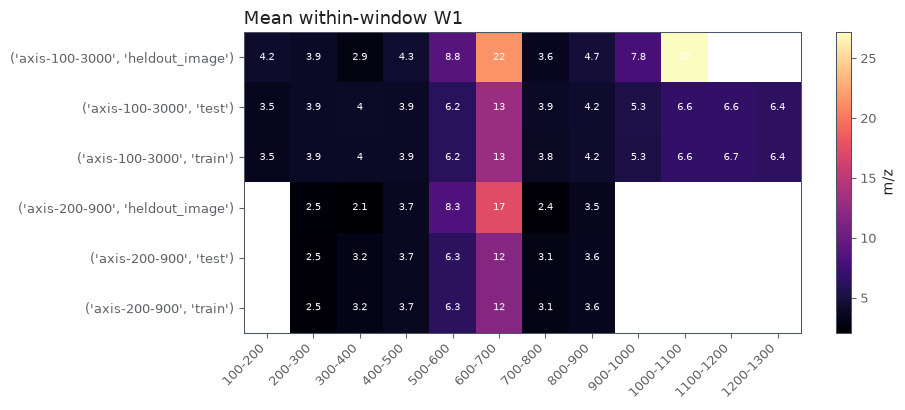

In [3]:
overall = window_errors[window_errors.group == 'all']
matrix = overall.pivot_table(index=['axis', 'population'], columns='window_label', values='within')
matrix = matrix[sorted(matrix.columns, key=lambda label: float(label.split('-')[0]))].dropna(axis=1, how='all')
figures.matrix_heatmap(matrix, title='Mean within-window W1', colorbar_label='m/z', annotate=True, theme=theme);
display(table('worst_windows').dropna(subset=['heldout_minus_test']).head(10))

### Remarks

- Held-out minus test differences are largest in the low-mass windows 600-700 and 1000-1100 m/z on both axes.

### Notes

## Error against input intensity

### Methodology

#### Theoretical

Low-intensity pixels have noisier TIC-normalized spectra; if they dominate the error, the error is a property of
the data rather than of the model.

#### Implementation

`tic_dependence` (mean $W_1$ and cosine per raw-TIC decile).

#### Figure descriptions

x = median raw TIC of the decile (log), y = mean $W_1$; colour = population, one line per repetition; panels = axes.

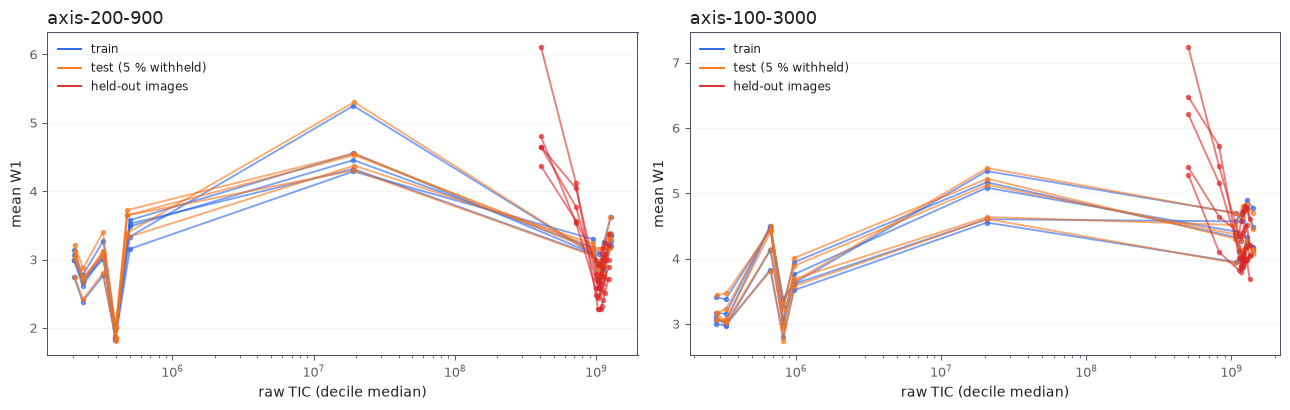

In [4]:
tic = table('tic_dependence')
figure, axes = plt.subplots(1, 2, figsize=(13, 4.2), dpi=theme.figure_dpi)
for ax, axis in zip(axes, [NARROW, WIDE]):
    figures.line_by_repetition(tic[tic.axis == axis], x='tic_median', y='masserstein_mean', color_by='population', levels=['train', 'test', 'heldout_image'], colors=POPULATION_COLORS, xlabel='raw TIC (decile median)', ylabel='mean W1', title=axis, log_x=True, ax=ax, theme=theme)
figure.tight_layout()

### Remarks

- On held-out images the lowest TIC decile has the highest error (4.9 narrow, 6.1 wide vs about 2.6-4.3 above); on train/test the TIC dependence is weak and non-monotonic.

### Notes

## Error against distance to the tissue border

### Methodology

#### Theoretical

Border pixels mix tissue and background signal; a strong border effect localizes the held-out error spatially.

#### Implementation

`edge_dependence` (held-out pixels, distance buckets).

#### Figure descriptions

x = distance bucket (pixels), y = mean $W_1$; colour = axis, one point per image and repetition.

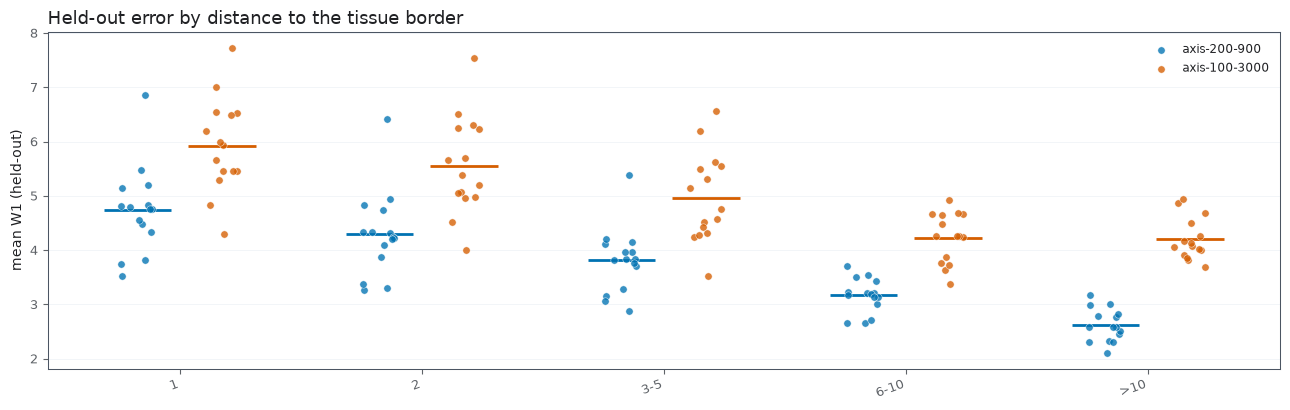

In [5]:
edges = table('edge_dependence')
edges['edge_distance'] = edges.edge_distance.astype(str)
figures.repetition_points(edges, value='mean', group='edge_distance', hue='axis', order=['1', '2', '3-5', '6-10', '>10'], hue_order=[NARROW, WIDE], colors=AXIS_COLORS, ylabel='mean W1 (held-out)', title='Held-out error by distance to the tissue border', theme=theme);

### Remarks

- Error decreases monotonically with the distance to the tissue border: 4.7 -> 2.6 (narrow) and 5.9 -> 4.2 (wide) from border pixels to pixels more than 10 pixels inside.

### Notes

## Prediction error against reconstruction error of the class window

### Methodology

#### Theoretical

If a class is predicted poorly because its m/z region is reconstructed poorly, per-class AP falls with the
within-window cost of the class window.

#### Implementation

`class_errors`: per class AP (test + extension, annotation retrieval) and the test within-window cost of its window; repetition means.

#### Figure descriptions

x = within-window cost of the class window (test), y = AP; colour = axis.

average_precision  window_within_test
axis                                                                   
axis-100-3000 average_precision              1.0000             -0.0951
              window_within_test            -0.0951              1.0000
axis-200-900  average_precision              1.0000             -0.0365
              window_within_test            -0.0365              1.0000

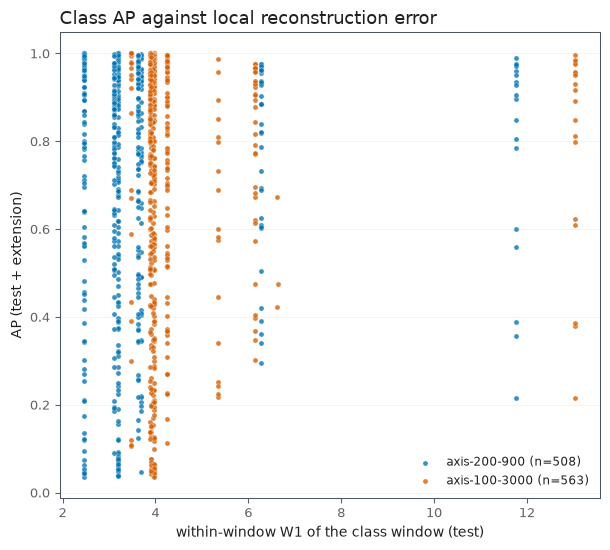

In [6]:
classes = table('class_errors')
classes = classes[classes.eligible.astype(bool)].groupby(['axis', 'class_name'], as_index=False)[['average_precision', 'window_within_test']].mean()
figures.paired_scatter(classes, x='window_within_test', y='average_precision', hue='axis', hue_order=[NARROW, WIDE], xlabel='within-window W1 of the class window (test)', ylabel='AP (test + extension)', title='Class AP against local reconstruction error', diagonal=False, colors=AXIS_COLORS, theme=theme);
display(classes.groupby('axis')[['average_precision', 'window_within_test']].corr(method='spearman'))

### Remarks

- Per-class AP is unrelated to the local reconstruction error of the class window (Spearman -0.04 narrow, -0.10 wide).

### Notes

## Results / Summary

### LLM

- **Observed:** reconstruction errors concentrate in low-mass m/z windows (500-700, 900-1100), at the tissue border and in the lowest-intensity held-out pixels, on both axes.
- **Observed:** prediction errors are not explained by the reconstruction error of the class's m/z window.
- **Interpretation:** the two tasks fail for different reasons: reconstruction where signal is weak, prediction where the image is new. Improvements of reconstruction (for example by pretraining) cannot be expected to fix the head's image-level generalization by themselves (hypothesis to be tested with the pretrained models).

### Person